# Fine-tuning Pre-trained Model for Perturbation Prediction

In [7]:
import json
import os
import sys
import time
import copy
from pathlib import Path
from typing import Iterable, List, Tuple, Dict, Union, Optional
import warnings

import torch
import numpy as np
import matplotlib
from torch import nn
from torch.nn import functional as F
from torchtext.vocab import Vocab
from torchtext._torchtext import (
    Vocab as VocabPybind,
)
from torch_geometric.loader import DataLoader
from gears import PertData, GEARS
from gears.inference import compute_metrics, deeper_analysis, non_dropout_analysis
from gears.utils import create_cell_graph_dataset_for_prediction

sys.path.insert(0, "../")

import scgpt as scg
from scgpt.model import TransformerGenerator
from scgpt.loss import (
    masked_mse_loss,
    criterion_neg_log_bernoulli,
    masked_relative_error,
)
from scgpt.tokenizer import tokenize_batch, pad_batch, tokenize_and_pad_batch
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.utils import set_seed, map_raw_id_to_vocab_id, compute_perturbation_metrics

matplotlib.rcParams["savefig.transparent"] = False
warnings.filterwarnings("ignore")

set_seed(42)


 ## Training Settings

In [2]:
# settings for data prcocessing
pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
pad_value = 0  # for padding values
pert_pad_id = 0
include_zero_gene = "all"
max_seq_len = 1536

# settings for training
MLM = True  # whether to use masked language modeling, currently it is always on.
CLS = False  # celltype classification objective
CCE = False  # Contrastive cell embedding objective
MVC = False  # Masked value prediction for cell embedding
ECS = False  # Elastic cell similarity objective
amp = True
load_model = "../../model_checkpoints/scGPT_human"
load_param_prefixs = [
    "encoder",
    "value_encoder",
    "transformer_encoder",
]

# settings for optimizer
lr = 1e-4  # or 1e-4
batch_size = 100 #was 64
eval_batch_size = 96 # was 64
epochs = 15 #was 15
schedule_interval = 1
early_stop = 10

# settings for the model
embsize = 512  # embedding dimension
d_hid = 512  # dimension of the feedforward network model in nn.TransformerEncoder
nlayers = 12  # number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 8  # number of heads in nn.MultiheadAttention
n_layers_cls = 3
dropout = 0  # dropout probability
use_fast_transformer = False  # whether to use fast transformer

# logging
log_interval = 50

# dataset and evaluation choices
data_name = "adamson"
split = "simulation"
if data_name == "norman":
    perts_to_plot = ["SAMD1+ZBTB1"]
elif data_name == "adamson":
    perts_to_plot = ["KCTD16+ctrl"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
save_dir = Path(f"./save/dev_perturb_{data_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"saving to {save_dir}")

logger = scg.logger
scg.utils.add_file_handler(logger, save_dir / "run.log")
# log running date and current git commit
logger.info(f"Running on {time.strftime('%Y-%m-%d %H:%M:%S')}")



saving to save/dev_perturb_adamson-Mar04-20-22
scGPT - INFO - Running on 2026-03-04 20:22:04


### use all data

In [4]:
pert_data = PertData("./data")
pert_data.load(data_name=data_name)
pert_data.prepare_split(split=split, seed=1)
pert_data.get_dataloader(batch_size=batch_size, test_batch_size=eval_batch_size)


Found local copy...
Local copy of pyg dataset is detected. Loading...
Done!
Local copy of split is detected. Loading...
Simulation split test composition:
combo_seen0:0
combo_seen1:0
combo_seen2:0
unseen_single:22
Done!
Creating dataloaders....
Done!


### use just a fraction to test

In [5]:
if load_model is not None:
    model_dir = Path(load_model)
    model_config_file = model_dir / "args.json"
    model_file = model_dir / "best_model.pt"
    vocab_file = model_dir / "vocab.json"

    vocab = GeneVocab.from_file(vocab_file)
    for s in special_tokens:
        if s not in vocab:
            vocab.append_token(s)

    pert_data.adata.var["id_in_vocab"] = [
        1 if gene in vocab else -1 for gene in pert_data.adata.var["gene_name"]
    ]
    gene_ids_in_vocab = np.array(pert_data.adata.var["id_in_vocab"])
    logger.info(
        f"match {np.sum(gene_ids_in_vocab >= 0)}/{len(gene_ids_in_vocab)} genes "
        f"in vocabulary of size {len(vocab)}."
    )
    genes = pert_data.adata.var["gene_name"].tolist()

    # model
    with open(model_config_file, "r") as f:
        model_configs = json.load(f)
    logger.info(
        f"Resume model from {model_file}, the model args will override the "
        f"config {model_config_file}."
    )
    embsize = model_configs["embsize"]
    nhead = model_configs["nheads"]
    d_hid = model_configs["d_hid"]
    nlayers = model_configs["nlayers"]
    n_layers_cls = model_configs["n_layers_cls"]
else:
    genes = pert_data.adata.var["gene_name"].tolist()
    vocab = Vocab(
        VocabPybind(genes + special_tokens, None)
    )  # bidirectional lookup [gene <-> int]
vocab.set_default_index(vocab["<pad>"])
gene_ids = np.array(
    [vocab[gene] if gene in vocab else vocab["<pad>"] for gene in genes], dtype=int
)
n_genes = len(genes)



scGPT - INFO - match 4399/5060 genes in vocabulary of size 60697.
scGPT - INFO - Resume model from ../../model_checkpoints/scGPT_human/best_model.pt, the model args will override the config ../../model_checkpoints/scGPT_human/args.json.


 # Create and train scGpt

In [6]:
ntokens = len(vocab)  # size of vocabulary
model = TransformerGenerator(
    ntokens,
    embsize,
    nhead,
    d_hid,
    nlayers,
    nlayers_cls=n_layers_cls,
    n_cls=1,
    vocab=vocab,
    dropout=dropout,
    pad_token=pad_token,
    pad_value=pad_value,
    pert_pad_id=pert_pad_id,
    use_fast_transformer=use_fast_transformer,
)
#



In [7]:
if load_model is not None:
    # Load the checkpoint
    pretrained_dict = torch.load(model_file)
    model_dict = model.state_dict()

    # Filter for prefixes AND ensure the key exists in the current model with matching shape
    filtered_dict = {
        k: v for k, v in pretrained_dict.items()
        if any(k.startswith(prefix) for prefix in load_param_prefixs)
        and k in model_dict 
        and v.shape == model_dict[k].shape
    }

    for k in filtered_dict.keys():
        logger.info(f"Successfully matched and loading: {k}")

    # Use strict=False to bypass the naming mismatch for attention layers
    missing_keys, unexpected_keys = model.load_state_dict(filtered_dict, strict=False)
    
    logger.info(f"Loaded {len(filtered_dict)} parameters.")
    if missing_keys:
        logger.warning(f"These layers will be randomly initialized: {missing_keys[:3]}... (and others)")

model.to(device)

scGPT - INFO - Successfully matched and loading: encoder.embedding.weight
scGPT - INFO - Successfully matched and loading: encoder.enc_norm.weight
scGPT - INFO - Successfully matched and loading: encoder.enc_norm.bias
scGPT - INFO - Successfully matched and loading: value_encoder.linear1.weight
scGPT - INFO - Successfully matched and loading: value_encoder.linear1.bias
scGPT - INFO - Successfully matched and loading: value_encoder.linear2.weight
scGPT - INFO - Successfully matched and loading: value_encoder.linear2.bias
scGPT - INFO - Successfully matched and loading: value_encoder.norm.weight
scGPT - INFO - Successfully matched and loading: value_encoder.norm.bias
scGPT - INFO - Successfully matched and loading: transformer_encoder.layers.0.self_attn.out_proj.weight
scGPT - INFO - Successfully matched and loading: transformer_encoder.layers.0.self_attn.out_proj.bias
scGPT - INFO - Successfully matched and loading: transformer_encoder.layers.0.linear1.weight
scGPT - INFO - Successfully

TransformerGenerator(
  (encoder): GeneEncoder(
    (embedding): Embedding(60697, 512, padding_idx=60694)
    (enc_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): ContinuousValueEncoder(
    (dropout): Dropout(p=0, inplace=False)
    (linear1): Linear(in_features=1, out_features=512, bias=True)
    (activation): ReLU()
    (linear2): Linear(in_features=512, out_features=512, bias=True)
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (pert_encoder): Embedding(3, 512, padding_idx=0)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0, inplace=False)
        (linear2): Linear(in_features=512, out_features=512, bias=Tru

In [8]:

criterion = masked_mse_loss
criterion_cls = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, schedule_interval, gamma=0.9)
scaler = torch.cuda.amp.GradScaler(enabled=amp)


def train(model: nn.Module, train_loader: torch.utils.data.DataLoader) -> None:
    """
    Train the model for one epoch.
    """
    model.train()
    total_loss, total_mse = 0.0, 0.0
    start_time = time.time()

    num_batches = len(train_loader)
    for batch, batch_data in enumerate(train_loader):
        batch_size = len(batch_data.y)
        batch_data.to(device)
        x: torch.Tensor = batch_data.x  # (batch_size * n_genes, 2)
        ori_gene_values = x[:, 0].view(batch_size, n_genes)
        pert_flags = x[:, 1].long().view(batch_size, n_genes)
        target_gene_values = batch_data.y  # (batch_size, n_genes)

        if include_zero_gene in ["all", "batch-wise"]:
            if include_zero_gene == "all":
                input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
            else:
                input_gene_ids = (
                    ori_gene_values.nonzero()[:, 1].flatten().unique().sort()[0]
                )
            # sample input_gene_id
            if len(input_gene_ids) > max_seq_len:
                input_gene_ids = torch.randperm(len(input_gene_ids), device=device)[
                    :max_seq_len
                ]
            input_values = ori_gene_values[:, input_gene_ids]
            input_pert_flags = pert_flags[:, input_gene_ids]
            target_values = target_gene_values[:, input_gene_ids]

            mapped_input_gene_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids)
            mapped_input_gene_ids = mapped_input_gene_ids.repeat(batch_size, 1)

            # src_key_padding_mask = mapped_input_gene_ids.eq(vocab[pad_token])
            src_key_padding_mask = torch.zeros_like(
                input_values, dtype=torch.bool, device=device
            )

        with torch.cuda.amp.autocast(enabled=amp):
            output_dict = model(
                mapped_input_gene_ids,
                input_values,
                input_pert_flags,
                src_key_padding_mask=src_key_padding_mask,
                CLS=CLS,
                CCE=CCE,
                MVC=MVC,
                ECS=ECS,
            )
            output_values = output_dict["mlm_output"]

            masked_positions = torch.ones_like(
                input_values, dtype=torch.bool
            )  # Use all
            loss = loss_mse = criterion(output_values, target_values, masked_positions)

        model.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        with warnings.catch_warnings(record=True) as w:
            warnings.filterwarnings("always")
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
                error_if_nonfinite=False if scaler.is_enabled() else True,
            )
            if len(w) > 0:
                logger.warning(
                    f"Found infinite gradient. This may be caused by the gradient "
                    f"scaler. The current scale is {scaler.get_scale()}. This warning "
                    "can be ignored if no longer occurs after autoscaling of the scaler."
                )
        scaler.step(optimizer)
        scaler.update()

        # torch.cuda.empty_cache()

        total_loss += loss.item()
        total_mse += loss_mse.item()
        if batch % log_interval == 0 and batch > 0:
            lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            cur_mse = total_mse / log_interval
            # ppl = math.exp(cur_loss)
            logger.info(
                f"| epoch {epoch:3d} | {batch:3d}/{num_batches:3d} batches | "
                f"lr {lr:05.4f} | ms/batch {ms_per_batch:5.2f} | "
                f"loss {cur_loss:5.2f} | mse {cur_mse:5.2f} |"
            )
            total_loss = 0
            total_mse = 0
            start_time = time.time()



In [9]:
def eval_perturb(
    loader: DataLoader, model: TransformerGenerator, device: torch.device
) -> Dict:
    """
    Run model in inference mode using a given data loader
    """

    model.eval()
    model.to(device)
    pert_cat = []
    pred = []
    truth = []
    pred_de = []
    truth_de = []
    results = {}
    logvar = []

    for itr, batch in enumerate(loader):
        batch.to(device)
        pert_cat.extend(batch.pert)

        with torch.no_grad():
            p = model.pred_perturb(
                batch,
                include_zero_gene=include_zero_gene,
                gene_ids=gene_ids,
            )
            t = batch.y
            pred.extend(p.cpu())
            truth.extend(t.cpu())

            # Differentially expressed genes
            for itr, de_idx in enumerate(batch.de_idx):
                pred_de.append(p[itr, de_idx])
                truth_de.append(t[itr, de_idx])

    # all genes
    results["pert_cat"] = np.array(pert_cat)
    pred = torch.stack(pred)
    truth = torch.stack(truth)
    
    # FIX: Replaced np.float with np.float64 for NumPy 2.0 compatibility 
    # and high-precision metric calculation.
    results["pred"] = pred.detach().cpu().numpy().astype(np.float64)
    results["truth"] = truth.detach().cpu().numpy().astype(np.float64)

    pred_de = torch.stack(pred_de)
    truth_de = torch.stack(truth_de)
    
    # FIX: Modernized type casting for DE genes
    results["pred_de"] = pred_de.detach().cpu().numpy().astype(np.float64)
    results["truth_de"] = truth_de.detach().cpu().numpy().astype(np.float64)

    return results

In [ ]:
best_val_loss = float("inf")
best_val_corr = 0
best_model = None
patience = 0

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train_loader = pert_data.dataloader["train_loader"]
    valid_loader = pert_data.dataloader["val_loader"]

    train(
        model,
        train_loader,
    )

    val_res = eval_perturb(valid_loader, model, device)
    val_metrics = compute_perturbation_metrics(
        val_res, pert_data.adata[pert_data.adata.obs["condition"] == "ctrl"]
    )
    logger.info(f"val_metrics at epoch {epoch}: ")
    logger.info(val_metrics)

    elapsed = time.time() - epoch_start_time
    logger.info(f"| end of epoch {epoch:3d} | time: {elapsed:5.2f}s | ")

    val_score = val_metrics["pearson"]
    if val_score > best_val_corr:
        best_val_corr = val_score
        best_model = copy.deepcopy(model)
        logger.info(f"Best model with score {val_score:5.4f}")
        patience = 0
    else:
        patience += 1
        if patience >= early_stop:
            logger.info(f"Early stop at epoch {epoch}")
            break

    # torch.save(
    #     model.state_dict(),
    #     save_dir / f"model_{epoch}.pt",
    # )

    scheduler.step()



scGPT - INFO - | epoch   1 |  50/543 batches | lr 0.0001 | ms/batch 1693.69 | loss  0.11 | mse  0.11 |
scGPT - INFO - | epoch   1 | 100/543 batches | lr 0.0001 | ms/batch 1638.49 | loss  0.10 | mse  0.10 |
scGPT - INFO - | epoch   1 | 150/543 batches | lr 0.0001 | ms/batch 1636.82 | loss  0.10 | mse  0.10 |
scGPT - INFO - | epoch   1 | 200/543 batches | lr 0.0001 | ms/batch 1637.19 | loss  0.10 | mse  0.10 |
scGPT - INFO - | epoch   1 | 250/543 batches | lr 0.0001 | ms/batch 1639.50 | loss  0.10 | mse  0.10 |
scGPT - INFO - | epoch   1 | 300/543 batches | lr 0.0001 | ms/batch 1640.90 | loss  0.09 | mse  0.09 |
scGPT - INFO - | epoch   1 | 350/543 batches | lr 0.0001 | ms/batch 1640.63 | loss  0.09 | mse  0.09 |
scGPT - INFO - | epoch   1 | 400/543 batches | lr 0.0001 | ms/batch 1640.73 | loss  0.09 | mse  0.09 |
scGPT - INFO - | epoch   1 | 450/543 batches | lr 0.0001 | ms/batch 1640.66 | loss  0.09 | mse  0.09 |
scGPT - INFO - | epoch   1 | 500/543 batches | lr 0.0001 | ms/batch 1640.

### save model

## Load the Model for Testing

 ## Evaluations

In [16]:
def predict(
    model: TransformerGenerator, pert_list: List[str], pool_size: Optional[int] = None
) -> Dict:
    """
    Predict the gene expression values for the given perturbations.

    Args:
        model (:class:`torch.nn.Module`): The model to use for prediction.
        pert_list (:obj:`List[str]`): The list of perturbations to predict.
        pool_size (:obj:`int`, optional): For each perturbation, use this number
            of cells in the control and predict their perturbation results. Report
            the stats of these predictions. If `None`, use all control cells.
    """
    adata = pert_data.adata
    ctrl_adata = adata[adata.obs["condition"] == "ctrl"]
    if pool_size is None:
        pool_size = len(ctrl_adata.obs)
    gene_list = pert_data.gene_names.values.tolist()
    for pert in pert_list:
        for i in pert:
            if i not in gene_list:
                raise ValueError(
                    "The gene is not in the perturbation graph. Please select from GEARS.gene_list!"
                )

    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        results_pred = {}
        for pert in pert_list:
            cell_graphs = create_cell_graph_dataset_for_prediction(
                pert, ctrl_adata, gene_list, device, num_samples=pool_size
            )
            loader = DataLoader(cell_graphs, batch_size=eval_batch_size, shuffle=False)
            preds = []
            for batch_data in loader:
                pred_gene_values = model.pred_perturb(
                    batch_data, include_zero_gene, gene_ids=gene_ids, amp=amp
                )
                preds.append(pred_gene_values)
            preds = torch.cat(preds, dim=0)
            results_pred["_".join(pert)] = np.mean(preds.detach().cpu().numpy(), axis=0)

    return results_pred



In [8]:
def plot_perturbation(
    model: nn.Module, query: str, save_file: str = None, pool_size: int = None
) -> matplotlib.figure.Figure:
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    sns.set_theme(style="ticks", rc={"axes.facecolor": (0, 0, 0, 0)}, font_scale=1.5)

    adata = pert_data.adata
    gene2idx = pert_data.node_map
    cond2name = dict(adata.obs[["condition", "condition_name"]].values)
    gene_raw2id = dict(zip(adata.var.index.values, adata.var.gene_name.values))

    de_idx = [
        gene2idx[gene_raw2id[i]]
        for i in adata.uns["top_non_dropout_de_20"][cond2name[query]]
    ]
    genes = [
        gene_raw2id[i] for i in adata.uns["top_non_dropout_de_20"][cond2name[query]]
    ]
    truth = adata[adata.obs.condition == query].X.toarray()[:, de_idx]
    if query.split("+")[1] == "ctrl":
        pred = predict(model, [[query.split("+")[0]]], pool_size=pool_size)
        pred = pred[query.split("+")[0]][de_idx]
    else:
        pred = predict(model, [query.split("+")], pool_size=pool_size)
        pred = pred["_".join(query.split("+"))][de_idx]
    ctrl_means = adata[adata.obs["condition"] == "ctrl"].to_df().mean()[de_idx].values

    pred = pred - ctrl_means
    truth = truth - ctrl_means

    fig, ax = plt.subplots(figsize=[16.5, 4.5])
    plt.title(query)
    plt.boxplot(truth, showfliers=False, medianprops=dict(linewidth=0))

    for i in range(pred.shape[0]):
        _ = plt.scatter(i + 1, pred[i], color="red")

    plt.axhline(0, linestyle="dashed", color="green")

    ax.xaxis.set_ticklabels(genes, rotation=90)

    plt.ylabel("Change in Gene Expression over Control", labelpad=10)
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tick_params(axis="y", which="major", pad=5)
    sns.despine()

    if save_file:
        fig.savefig(save_file, bbox_inches="tight", transparent=False)

    return fig

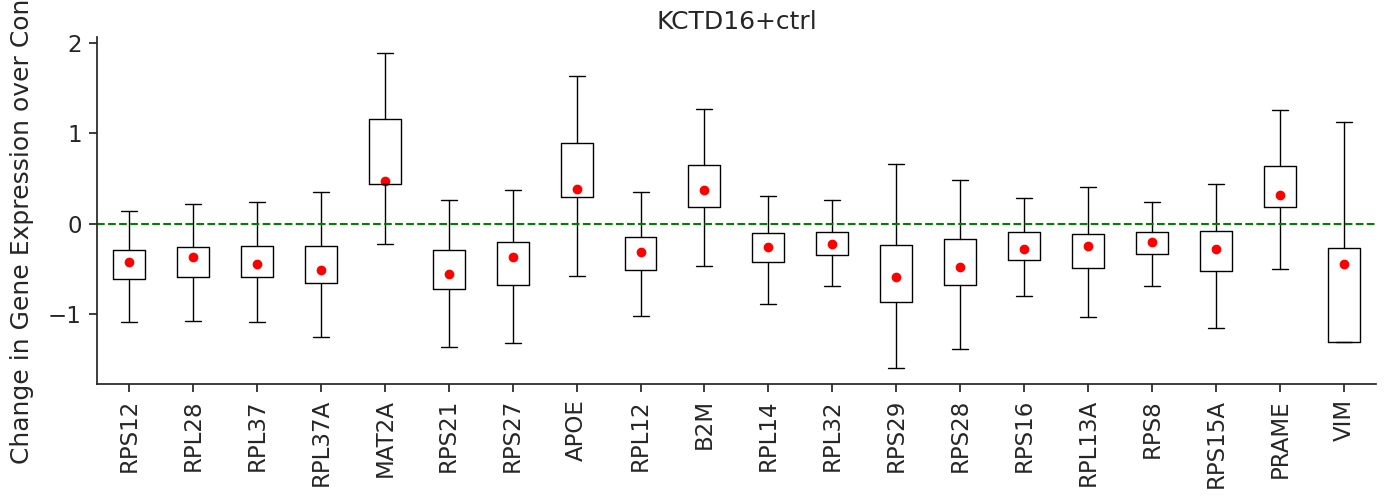

In [18]:
# predict(best_model, [["FEV"], ["FEV", "SAMD11"]])
for p in perts_to_plot:
    plot_perturbation(best_model, p, pool_size=300, save_file=f"{save_dir}/{p}.png")



In [19]:
test_loader = pert_data.dataloader["test_loader"]
test_res = eval_perturb(test_loader, best_model, device)
# test_metrics, test_pert_res = compute_metrics(test_res)
test_metrics = compute_perturbation_metrics(
    test_res, pert_data.adata[pert_data.adata.obs["condition"] == "ctrl"]
)
print(test_metrics)

# save the dicts in json
with open(f"{save_dir}/test_metrics.json", "w") as f:
    json.dump(test_metrics, f)
# with open(f"{save_dir}/test_pert_res.json", "w") as f:
#     json.dump(test_pert_res, f)

deeper_res = deeper_analysis(pert_data.adata, test_res)
non_dropout_res = non_dropout_analysis(pert_data.adata, test_res)

metrics = ["pearson_delta", "pearson_delta_de"]
metrics_non_dropout = [
    "pearson_delta_top20_de_non_dropout",
    "pearson_top20_de_non_dropout",
]
subgroup_analysis = {}
for name in pert_data.subgroup["test_subgroup"].keys():
    subgroup_analysis[name] = {}
    for m in metrics:
        subgroup_analysis[name][m] = []

    for m in metrics_non_dropout:
        subgroup_analysis[name][m] = []

for name, pert_list in pert_data.subgroup["test_subgroup"].items():
    for pert in pert_list:
        for m in metrics:
            subgroup_analysis[name][m].append(deeper_res[pert][m])

        for m in metrics_non_dropout:
            subgroup_analysis[name][m].append(non_dropout_res[pert][m])

for name, result in subgroup_analysis.items():
    for m in result.keys():
        mean_value = np.mean(subgroup_analysis[name][m])
        logger.info("test_" + name + "_" + m + ": " + str(mean_value))


{'pearson': np.float64(0.9896107673621326), 'pearson_de': np.float64(0.9771572806723993), 'pearson_delta': np.float64(0.6111030410618098), 'pearson_de_delta': np.float64(0.789258528106485)}
scGPT - INFO - test_combo_seen0_pearson_delta: nan
scGPT - INFO - test_combo_seen0_pearson_delta_de: nan
scGPT - INFO - test_combo_seen0_pearson_delta_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen0_pearson_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen1_pearson_delta: nan
scGPT - INFO - test_combo_seen1_pearson_delta_de: nan
scGPT - INFO - test_combo_seen1_pearson_delta_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen1_pearson_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen2_pearson_delta: nan
scGPT - INFO - test_combo_seen2_pearson_delta_de: nan
scGPT - INFO - test_combo_seen2_pearson_delta_top20_de_non_dropout: nan
scGPT - INFO - test_combo_seen2_pearson_top20_de_non_dropout: nan
scGPT - INFO - test_unseen_single_pearson_delta: 0.6111030410618099
scGPT - INFO 

### load saved model again

In [3]:
import json
import torch
import numpy as np
from pathlib import Path
from torch_geometric.loader import DataLoader
from gears import PertData
import scgpt as scg
from scgpt.model import TransformerGenerator
from scgpt.tokenizer.gene_tokenizer import GeneVocab

# --- 1. Variables and Paths ---
# Use the exact folder your model saved to
save_dir = Path("./save/dev_perturb_adamson-Mar04-20-22") 
load_model = "../../model_checkpoints/scGPT_human"

pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
pad_value = 0
pert_pad_id = 0
include_zero_gene = "all"
eval_batch_size = 96
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Reload Data and Splits ---
pert_data = PertData("./data")
pert_data.load(data_name="adamson")
pert_data.prepare_split(split="simulation", seed=1) # Same split and seed as training
pert_data.get_dataloader(batch_size=100, test_batch_size=eval_batch_size)

# --- 3. Rebuild Vocabulary ---
vocab_file = Path(load_model) / "vocab.json"
vocab = GeneVocab.from_file(vocab_file)
for s in special_tokens:
    if s not in vocab:
        vocab.append_token(s)

ntokens = len(vocab)
vocab.set_default_index(vocab["<pad>"])

genes = pert_data.adata.var["gene_name"].tolist()
gene_ids = np.array([vocab[gene] if gene in vocab else vocab["<pad>"] for gene in genes], dtype=int)

# --- 4. Load Model Configs and Weights ---
model_config_file = Path(load_model) / "args.json"
with open(model_config_file, "r") as f:
    model_configs = json.load(f)

embsize = model_configs["embsize"]
nhead = model_configs["nheads"]
d_hid = model_configs["d_hid"]
nlayers = model_configs["nlayers"]
n_layers_cls = model_configs["n_layers_cls"]

model = TransformerGenerator(
    ntokens,
    embsize,
    nhead,
    d_hid,
    nlayers,
    nlayers_cls=n_layers_cls,
    n_cls=1,
    vocab=vocab,
    dropout=0, # 0 for inference
    pad_token=pad_token,
    pad_value=pad_value,
    pert_pad_id=pert_pad_id,
    use_fast_transformer=False,
)

model.load_state_dict(torch.load(save_dir / "best_model.pt"))
model.to(device)
model.eval()
print("Model loaded successfully!")

Found local copy...
Local copy of pyg dataset is detected. Loading...
Done!
Local copy of split is detected. Loading...
Simulation split test composition:
combo_seen0:0
combo_seen1:0
combo_seen2:0
unseen_single:22
Done!
Creating dataloaders....
Done!


Model loaded successfully!


In [12]:
from typing import List, Optional, Dict
import matplotlib.figure

def predict(
    model: torch.nn.Module, pert_list: List[str], pool_size: Optional[int] = None
) -> Dict:
    """Predict the gene expression values for the given perturbations."""
    adata = pert_data.adata
    ctrl_adata = adata[adata.obs["condition"] == "ctrl"]
    if pool_size is None:
        pool_size = len(ctrl_adata.obs)
    gene_list = pert_data.gene_names.values.tolist()
    
    for pert in pert_list:
        for i in pert:
            if i not in gene_list and i != "ctrl": # Added a check to ignore 'ctrl'
                raise ValueError(
                    f"The gene {i} is not in the perturbation graph!"
                )

    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        results_pred = {}
        for pert in pert_list:
            # We import this specific GEARS function here
            from gears.utils import create_cell_graph_dataset_for_prediction
            cell_graphs = create_cell_graph_dataset_for_prediction(
                pert, ctrl_adata, gene_list, device, num_samples=pool_size
            )
            loader = DataLoader(cell_graphs, batch_size=eval_batch_size, shuffle=False)
            preds = []
            for batch_data in loader:
                pred_gene_values = model.pred_perturb(
                    batch_data, include_zero_gene, gene_ids=gene_ids, amp=True
                )
                preds.append(pred_gene_values)
            preds = torch.cat(preds, dim=0)
            results_pred["_".join(pert)] = np.mean(preds.detach().cpu().numpy(), axis=0)

    return results_pred


def plot_perturbation(
    model: torch.nn.Module, query: str, save_file: str = None, pool_size: int = None
) -> matplotlib.figure.Figure:
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="ticks", rc={"axes.facecolor": (0, 0, 0, 0)}, font_scale=1.5)

    adata = pert_data.adata
    gene2idx = pert_data.node_map
    cond2name = dict(adata.obs[["condition", "condition_name"]].values)
    gene_raw2id = dict(zip(adata.var.index.values, adata.var.gene_name.values))

    de_idx = [
        gene2idx[gene_raw2id[i]]
        for i in adata.uns["top_non_dropout_de_20"][cond2name[query]]
    ]
    genes = [
        gene_raw2id[i] for i in adata.uns["top_non_dropout_de_20"][cond2name[query]]
    ]
    truth = adata[adata.obs.condition == query].X.toarray()[:, de_idx]
    
    if query.split("+")[1] == "ctrl":
        pred = predict(model, [[query.split("+")[0]]], pool_size=pool_size)
        pred = pred[query.split("+")[0]][de_idx]
    else:
        pred = predict(model, [query.split("+")], pool_size=pool_size)
        pred = pred["_".join(query.split("+"))][de_idx]
        
    ctrl_means = adata[adata.obs["condition"] == "ctrl"].to_df().mean()[de_idx].values

    pred = pred - ctrl_means
    truth = truth - ctrl_means

    fig, ax = plt.subplots(figsize=[16.5, 4.5])
    plt.title(query)
    plt.boxplot(truth, showfliers=False, medianprops=dict(linewidth=0))

    for i in range(pred.shape[0]):
        _ = plt.scatter(i + 1, pred[i], color="red")

    plt.axhline(0, linestyle="dashed", color="green")
    ax.xaxis.set_ticklabels(genes, rotation=90)
    plt.ylabel("Change in Gene Expression over Control", labelpad=10)
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tick_params(axis="y", which="major", pad=5)
    sns.despine()

    if save_file:
        fig.savefig(save_file, bbox_inches="tight", transparent=False)

    return fig

In [13]:
# Look at the held-out test groups
print("Test sub-groups available:", pert_data.subgroup["test_subgroup"].keys())

# Grab the list of perturbations the model has NEVER seen
unseen_perts = pert_data.subgroup["test_subgroup"]["unseen_single"]
print(f"Number of unseen perturbations: {len(unseen_perts)}")
print(f"unseen: {unseen_perts[:]}")

# Pick one to test
query_pert = unseen_perts[0] 
print(f"We will plot: {query_pert}")

Test sub-groups available: dict_keys(['combo_seen0', 'combo_seen1', 'combo_seen2', 'unseen_single'])
Number of unseen perturbations: 22
unseen: ['CREB1+ctrl', 'BHLHE40+ctrl', 'IER3IP1+ctrl', 'DAD1+ctrl', 'AMIGO3+ctrl', 'DARS+ctrl', 'SYVN1+ctrl', 'GMPPB+ctrl', 'CAD+ctrl', 'GNPNAT1+ctrl', 'DERL2+ctrl', 'FARSB+ctrl', 'TARS+ctrl', 'TTI1+ctrl', 'TIMM44+ctrl', 'PTDSS1+ctrl', 'DDOST+ctrl', 'CHERP+ctrl', 'COPZ1+ctrl', 'DNAJC19+ctrl', 'XRN1+ctrl', 'SPCS2+ctrl']
We will plot: CREB1+ctrl


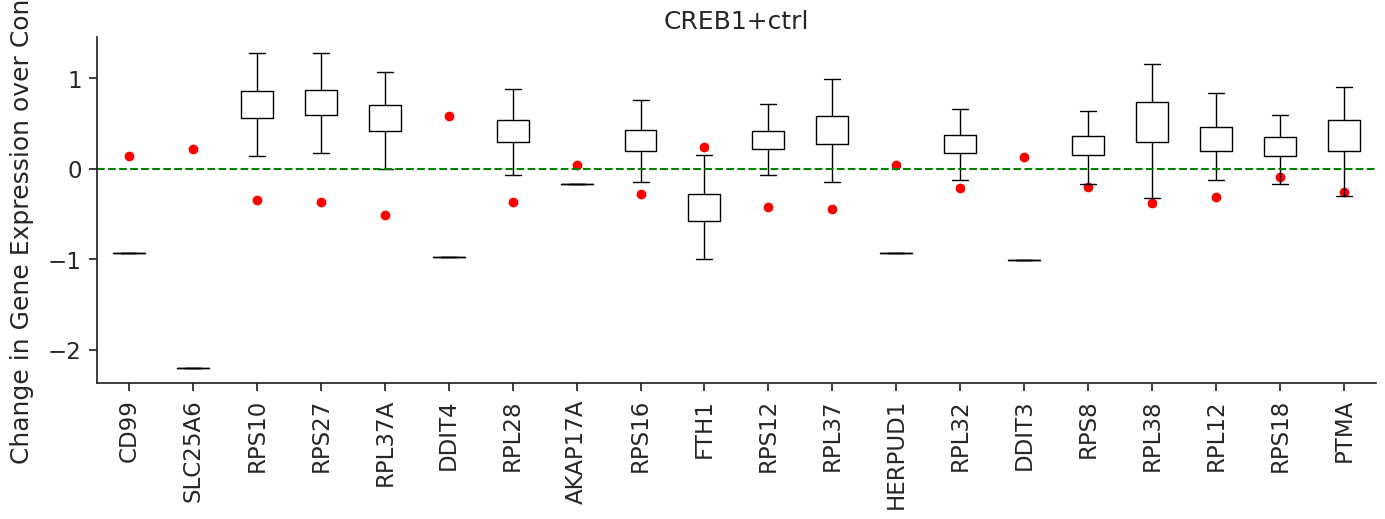

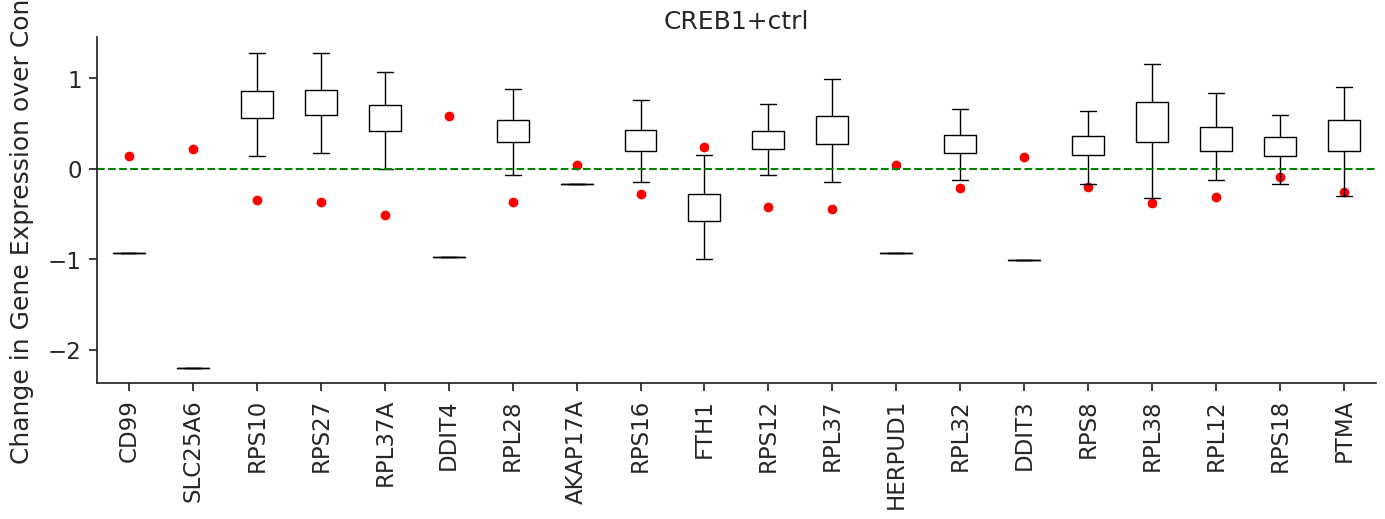

In [14]:
# Plot the held-out perturbation
plot_perturbation(
    model, 
    query_pert, 
    pool_size=300, 
   save_file=str(save_dir / f"test_eval_{query_pert}.png")
)